<a href="https://colab.research.google.com/github/PENGxiaun/Demand-Forecasting-and-Inventory-Logistics-Optimization-for-Turkish-Retail-Supply-Chain/blob/main/data%20cleaning%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data cleaning code

In [14]:
import kagglehub
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [15]:
# 1. Download the dataset
path = kagglehub.dataset_download("umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr")
csv_filename = "ecommerce_customer_behavior_dataset.csv"
full_path = os.path.join(path, csv_filename)

Using Colab cache for faster access to the 'e-commerce-customer-behavior-and-sales-analysis-tr' dataset.


In [16]:
# 2. Read the CSV file
df = pd.read_csv(full_path)

In [18]:
# 3. Basic data cleaning
df = df.drop_duplicates()
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=object).columns
# Fill missing values in numerical columns with the mean
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [19]:
# 4. Outlier detection function using IQR
def detect_outliers(df, columns):
    outliers_info = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliers_info[col] = {
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outliers_count": len(outliers),
            "outliers_index": outliers.index.tolist(),
            "outliers_data": outliers[col].values
        }
    return outliers_info


In [20]:
# 5. Run outlier detection
outliers_result = detect_outliers(df, num_cols)

In [22]:
# 6. Print outlier statistics
for col, info in outliers_result.items():
    print(f"{col}: {info['outliers_count']} extreme values")

    # Show some example extreme values
    if info['outliers_count'] > 0:
        print(f"Example extreme values in {col}: {info['outliers_data'][:5]}")

Age: 30 extreme values
Example extreme values in Age: [66 65 73 71 75]
Unit_Price: 513 extreme values
Example extreme values in Unit_Price: [2107.37 1784.75 1837.61 4136.98 1375.1 ]
Quantity: 0 extreme values
Discount_Amount: 879 extreme values
Example extreme values in Discount_Amount: [229.28  62.15 490.25 100.24 156.33]
Total_Amount: 546 extreme values
Example extreme values in Total_Amount: [3778.05 4214.74 6648.75 4485.1  3518.89]
Session_Duration_Minutes: 124 extreme values
Example extreme values in Session_Duration_Minutes: [48 36 38 52 36]
Pages_Viewed: 14 extreme values
Example extreme values in Pages_Viewed: [20 19 19 18 18]
Delivery_Time_Days: 141 extreme values
Example extreme values in Delivery_Time_Days: [17 17 15 16 16]
Customer_Rating: 0 extreme values


/tmp/ipykernel_248/2881582797.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(plot_data, labels=num_cols, patch_artist=True)


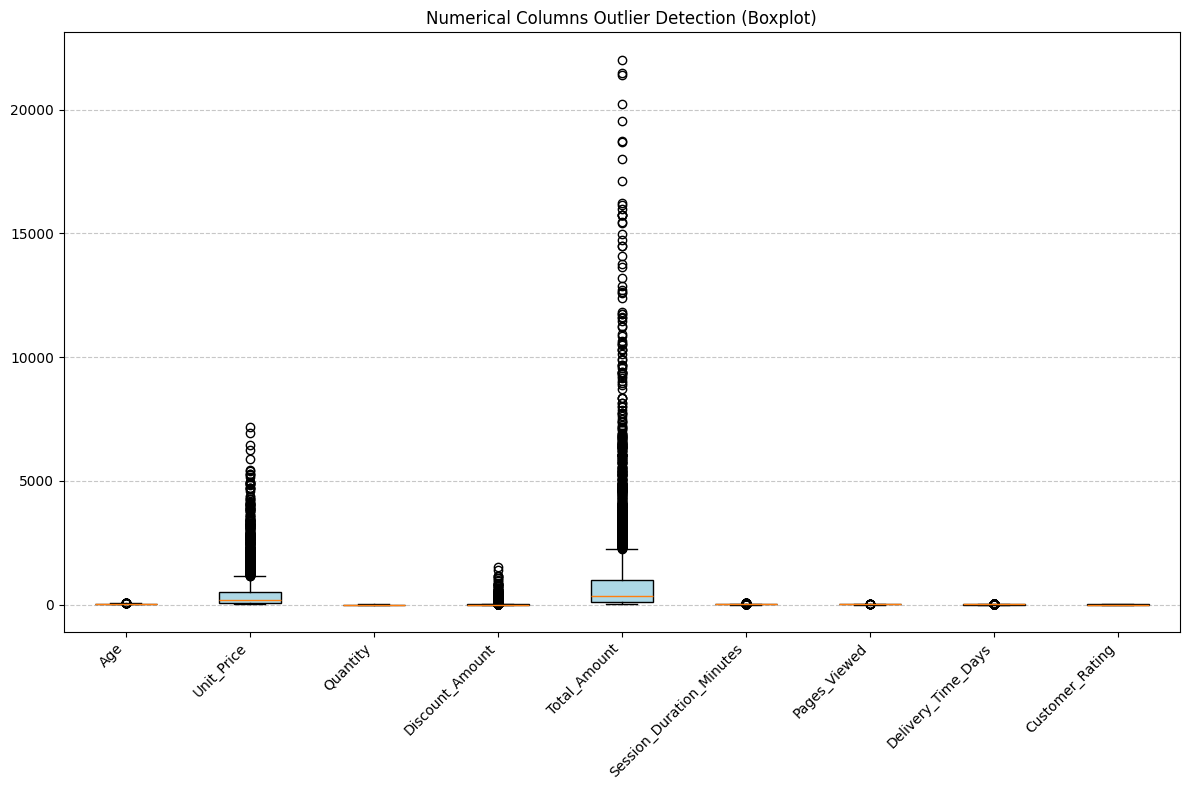

In [24]:
# 8. Boxplot visualization for numerical columns
plt.figure(figsize=(12,8))
plot_data = [df[col].values for col in num_cols]
box = plt.boxplot(plot_data, labels=num_cols, patch_artist=True)
for patch in box['boxes']:
    patch.set_facecolor('lightblue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Numerical Columns Outlier Detection (Boxplot)")
plt.tight_layout()
plt.show()

In [ ]:
# 9. Save the cleaned dataset to CSV and download
cleaned_csv_path = "/content/sales_data_clean.csv"
df.to_csv(cleaned_csv_path, index=False)
files.download(cleaned_csv_path)